# 01 — Data Exploration
نستعرض الداتا ونفهمها قبل ما نبدأ التدريب.

**هنشتغل على:** SIIM-ACR Pneumothorax Dataset (Kaggle)

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ahmedabdelkhaleq","key":"0c3631a42e133f4cafc8a82211af6f01"}'}

In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API ready!")

✅ Kaggle API ready!


In [3]:
!kaggle datasets list | head -5

ref                                                                title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                     Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           8724        203                1  
nalisha/job-salary-prediction-dataset                              Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          14168        317                1  
arfeenkabir/customer-purchase-behavior-analysis                    Customer Purchase Behavior Analysis                      77715  2026-04-16 20:10:57.803000            797         22     

In [1]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/data/ --unzip
print("✅ X-Ray data downloaded!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:30<00:00, 80.9MB/s]

✅ X-Ray data downloaded!


In [5]:
import os
for folder in os.listdir('/content/data/chest_xray'):
    count = len(os.listdir(f'/content/data/chest_xray/{folder}'))
    print(f"{folder}: {count} files")

val: 2 files
__MACOSX: 2 files
train: 2 files
chest_xray: 4 files
test: 2 files


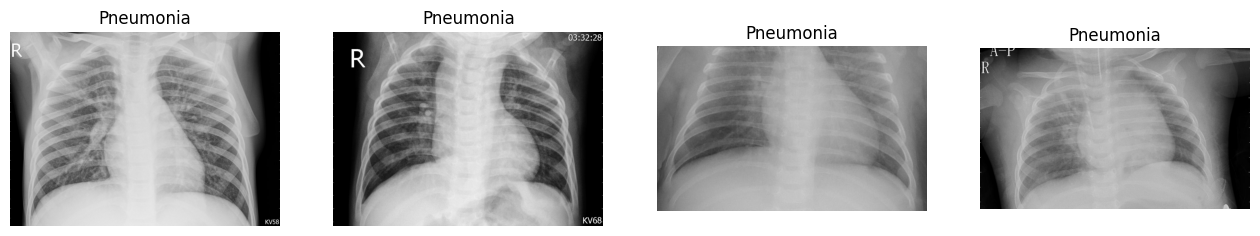

In [6]:
import matplotlib.pyplot as plt
import cv2, glob

images = glob.glob('/content/data/chest_xray/train/PNEUMONIA/*.jpeg')[:4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, path in zip(axes, images):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title('Pneumonia')
    ax.axis('off')
plt.show()

In [7]:
import os

base = '/content/data/chest_xray'
for split in ['train', 'val', 'test']:
    print(f"\n── {split.upper()} ──")
    for cls in os.listdir(f'{base}/{split}'):
        count = len(os.listdir(f'{base}/{split}/{cls}'))
        print(f"  {cls}: {count} images")


── TRAIN ──
  PNEUMONIA: 3875 images
  NORMAL: 1341 images

── VAL ──
  PNEUMONIA: 8 images
  NORMAL: 8 images

── TEST ──
  PNEUMONIA: 390 images
  NORMAL: 234 images


In [8]:
import pandas as pd
import glob

records = []
label_map = {'NORMAL': 0, 'PNEUMONIA': 1}

for split in ['train', 'val', 'test']:
    for cls, label in label_map.items():
        paths = glob.glob(f'{base}/{split}/{cls}/*')
        for path in paths:
            records.append({
                'image_path': path,
                'label':      label,
                'class_name': cls,
                'split':      split
            })

df = pd.DataFrame(records)
print(df.groupby(['split', 'class_name']).size())
print(f"\nTotal: {len(df)} images")
df.to_csv('/content/data/manifest.csv', index=False)
print("✅ Manifest saved!")

split  class_name
test   NORMAL         234
       PNEUMONIA      390
train  NORMAL        1341
       PNEUMONIA     3875
val    NORMAL           8
       PNEUMONIA        8
dtype: int64

Total: 5856 images
✅ Manifest saved!


In [9]:
!git clone https://github.com/AhmedAbdElkhalek16/acute-triage-system.git
%cd acute-triage-system
!pip install -q timm albumentations grad-cam gradio
print("✅ Ready!")

Cloning into 'acute-triage-system'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 0), reused 13 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 18.10 KiB | 18.10 MiB/s, done.
/content/acute-triage-system
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 79.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Ready!


In [10]:
import numpy as np
from torch.utils.data import WeightedRandomSampler

# احسب وزن كل class
class_counts = df[df['split']=='train']['label'].value_counts().sort_index()
print("Class counts:", class_counts.to_dict())

# الكلاس الأقل = وزن أكبر
class_weights = 1.0 / class_counts.values
print("Class weights:", class_weights)

# وزن كل sample بناءً على كلاسها
train_df = df[df['split'] == 'train'].reset_index(drop=True)
sample_weights = [class_weights[label] for label in train_df['label']]

# الـ Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)
print("✅ Sampler ready!")

Class counts: {0: 1341, 1: 3875}
Class weights: [0.00074571 0.00025806]
✅ Sampler ready!


In [11]:
# نشوف إن الـ sampler بيعطي توزيع متساوي
from collections import Counter

sample_indices = list(sampler)
sampled_labels = [train_df['label'][i] for i in sample_indices]
counts = Counter(sampled_labels)
print("After sampling:")
print(f"  NORMAL    : {counts[0]}")
print(f"  PNEUMONIA : {counts[1]}")
print(f"  Ratio     : {counts[1]/counts[0]:.2f}x  (هيبقى قريب من 1.0)")

After sampling:
  NORMAL    : 2613
  PNEUMONIA : 2603
  Ratio     : 1.00x  (هيبقى قريب من 1.0)


In [12]:
# الـ val فيها 16 صورة بس — ده مش كافي!
# هنقسم الـ train: 80% train / 20% val

from sklearn.model_selection import train_test_split

train_df = df[df['split'] == 'train'].reset_index(drop=True)

train_final, val_final = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['label'],   # نحافظ على نفس النسبة
    random_state=42
)

test_df = df[df['split'] == 'test'].reset_index(drop=True)

print(f"Train : {len(train_final)} images")
print(f"Val   : {len(val_final)} images")
print(f"Test  : {len(test_df)} images")

# احفظهم
train_final.to_csv('/content/data/train.csv', index=False)
val_final.to_csv('/content/data/val.csv', index=False)
test_df.to_csv('/content/data/test.csv', index=False)
print("✅ Splits saved!")

Train : 4172 images
Val   : 1044 images
Test  : 624 images
✅ Splits saved!


In [15]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 42.7 MB/s eta 0:00:00


In [18]:
import sys
sys.path.insert(0, '/content/acute-triage-system')

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, WeightedRandomSampler
from Src.preprocessing import XRayDataset, get_train_transforms, get_val_transforms

train_df = pd.read_csv('/content/data/train.csv').reset_index(drop=True)
val_df   = pd.read_csv('/content/data/val.csv').reset_index(drop=True)
test_df  = pd.read_csv('/content/data/test.csv').reset_index(drop=True)

# ── Sampler على الداتا الصح ──
class_counts  = train_df['label'].value_counts().sort_index()
class_weights = 1.0 / class_counts.values
sample_weights = [class_weights[label] for label in train_df['label']]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# ── Datasets ──
train_ds = XRayDataset(train_df, transforms=get_train_transforms())
val_ds   = XRayDataset(val_df,   transforms=get_val_transforms())
test_ds  = XRayDataset(test_df,  transforms=get_val_transforms())

# ── DataLoaders ──
train_dl = DataLoader(train_ds, batch_size=32, sampler=sampler,
                      num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False,
                      num_workers=2, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train : {len(train_ds)} images | {len(train_dl)} batches")
print(f"Val   : {len(val_ds)} images | {len(val_dl)} batches")
print(f"Test  : {len(test_ds)} images | {len(test_dl)} batches")
print("✅ DataLoaders ready!")

Train : 4172 images | 131 batches
Val   : 1044 images | 33 batches
Test  : 624 images | 20 batches
✅ DataLoaders ready!


In [19]:
imgs, labels = next(iter(train_dl))
print(f"Batch shape : {imgs.shape}")    # (32, 3, 512, 512)
print(f"Labels      : {labels[:8]}")
print(f"dtype       : {imgs.dtype}")
print(f"value range : {imgs.min():.2f} → {imgs.max():.2f}")

Batch shape : torch.Size([32, 3, 512, 512])
Labels      : tensor([0, 0, 0, 0, 0, 1, 1, 1])
dtype       : torch.float32
value range : -2.12 → 2.64


In [21]:
from Src.models import get_model

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

# نموذج X-Ray — بس هنستخدم num_classes=2 (Normal / Pneumonia)
model = get_model('xray', num_classes=2, pretrained=True, device=DEVICE)
model.freeze_backbone()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  ← الـ head بس")
print("✅ Model ready!")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

[XRayModel] Backbone frozen.
Total params    : 18,467,658
Trainable params: 919,042  ← الـ head بس
✅ Model ready!


In [22]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Training', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(imgs)
    return total_loss / total, correct / total

@torch.no_grad()
def val_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in tqdm(loader, desc='Validation', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * len(imgs)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(imgs)
    return total_loss / total, correct / total

print("✅ Training functions ready!")

✅ Training functions ready!


In [23]:
print("=" * 55)
print("  PHASE 1 — Training head only (backbone frozen)")
print("=" * 55)

best_val_acc = 0
history = []

for epoch in range(5):
    tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion)
    vl_loss, vl_acc = val_epoch(model, val_dl, criterion)
    scheduler.step()

    history.append({
        'epoch': epoch+1,
        'tr_loss': tr_loss, 'tr_acc': tr_acc,
        'vl_loss': vl_loss, 'vl_acc': vl_acc
    })

    print(f"Epoch {epoch+1:02d} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.3f}", end="")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/content/xray_phase1_best.pth')
        print("  ✅ saved")
    else:
        print()

print(f"\nBest Val Accuracy: {best_val_acc:.3f}")

  PHASE 1 — Training head only (backbone frozen)


Epoch 01 | Train loss 0.3474 acc 0.837 | Val loss 0.1678 acc 0.935  ✅ saved


Epoch 02 | Train loss 0.2587 acc 0.886 | Val loss 0.1704 acc 0.943  ✅ saved


Epoch 03 | Train loss 0.2614 acc 0.886 | Val loss 0.1034 acc 0.956  ✅ saved


Epoch 04 | Train loss 0.2380 acc 0.899 | Val loss 0.1330 acc 0.948


Epoch 05 | Train loss 0.2067 acc 0.913 | Val loss 0.0973 acc 0.962  ✅ saved

Best Val Accuracy: 0.962


In [24]:
# حمّل أحسن weights من Phase 1
model.load_state_dict(torch.load('/content/xray_phase1_best.pth'))

# فك تجميد آخر blocks
model.unfreeze_backbone(last_n_blocks=2)

# LR أصغر بكتير عشان نحرك الـ pretrained weights بلطف
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
    weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

print("=" * 55)
print("  PHASE 2 — Fine-tuning last 2 blocks")
print("=" * 55)

best_val_acc = 0

for epoch in range(10):
    tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion)
    vl_loss, vl_acc = val_epoch(model, val_dl, criterion)
    scheduler.step()

    history.append({
        'epoch': epoch+6,
        'tr_loss': tr_loss, 'tr_acc': tr_acc,
        'vl_loss': vl_loss, 'vl_acc': vl_acc
    })

    print(f"Epoch {epoch+1:02d} | "
          f"Train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"Val loss {vl_loss:.4f} acc {vl_acc:.3f}", end="")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), '/content/xray_best.pth')
        print("  ✅ saved")
    else:
        print()

print(f"\nBest Val Accuracy: {best_val_acc:.3f}")

[XRayModel] Unfroze last 2 blocks. Trainable params: 919,042
  PHASE 2 — Fine-tuning last 2 blocks


Epoch 01 | Train loss 0.2207 acc 0.906 | Val loss 0.0924 acc 0.965  ✅ saved


Epoch 02 | Train loss 0.2190 acc 0.909 | Val loss 0.1023 acc 0.960


Epoch 03 | Train loss 0.2091 acc 0.913 | Val loss 0.0949 acc 0.962


Epoch 04 | Train loss 0.2248 acc 0.903 | Val loss 0.0992 acc 0.959


...

Epoch 06 | Train loss 0.2154 acc 0.910 | Val loss 0.0967 acc 0.960


Epoch 07 | Train loss 0.2089 acc 0.911 | Val loss 0.0918 acc 0.962


Epoch 08 | Train loss 0.2161 acc 0.907 | Val loss 0.1087 acc 0.958


Epoch 09 | Train loss 0.2064 acc 0.916 | Val loss 0.0921 acc 0.962


Epoch 10 | Train loss 0.2202 acc 0.907 | Val loss 0.0949 acc 0.962

Best Val Accuracy: 0.965


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# حمّل أحسن model
model.load_state_dict(torch.load('/content/xray_best.pth'))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_dl:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("=" * 55)
print("  TEST SET RESULTS")
print("=" * 55)
print(classification_report(
    all_labels, all_preds,
    target_names=['Normal', 'Pneumonia']
))

  TEST SET RESULTS
              precision    recall  f1-score   support

      Normal       0.95      0.62      0.75       234
   Pneumonia       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.80      0.82       624
weighted avg       0.86      0.85      0.84       624



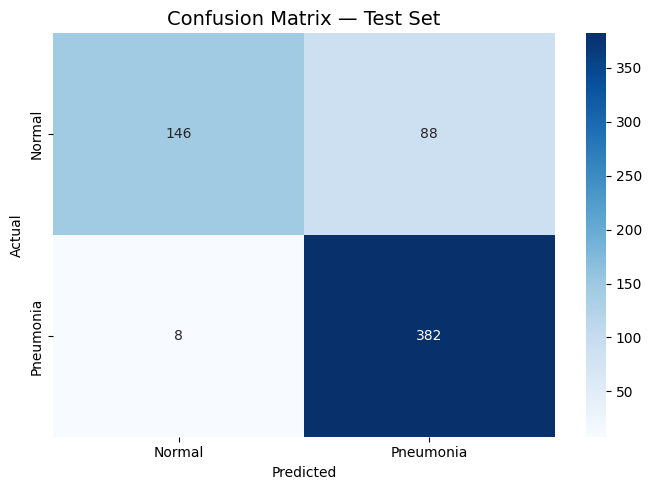


True Negatives  (Normal   → Normal)   : 146
False Positives (Normal   → Pneumonia): 88  ← أخطأ
False Negatives (Pneumonia→ Normal)   : 8  ← الأخطر طبياً!
True Positives  (Pneumonia→ Pneumonia): 382

Sensitivity (Recall) : 0.979  ← قدرته يكشف المرض
Specificity          : 0.624  ← قدرته يكشف السليم


In [26]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix — Test Set', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Normal   → Normal)   : {tn}")
print(f"False Positives (Normal   → Pneumonia): {fp}  ← أخطأ")
print(f"False Negatives (Pneumonia→ Normal)   : {fn}  ← الأخطر طبياً!")
print(f"True Positives  (Pneumonia→ Pneumonia): {tp}")
print(f"\nSensitivity (Recall) : {tp/(tp+fn):.3f}  ← قدرته يكشف المرض")
print(f"Specificity          : {tn/(tn+fp):.3f}  ← قدرته يكشف السليم")

In [28]:
# تنزيل الـ model على جهازك مباشرة
from google.colab import files
files.download('/content/xray_best.pth')
print("✅ Downloading model to your PC!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloading model to your PC!


In [29]:
# جرب thresholds مختلفة وشوف الأفضل
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("─" * 50)

pneumonia_probs = all_probs[:, 1]  # احتمال Pneumonia لكل صورة

for thresh in thresholds:
    preds_t = (pneumonia_probs >= thresh).astype(int)
    cm_t    = confusion_matrix(all_labels, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    sens = tp_t / (tp_t + fn_t)
    spec = tn_t / (tn_t + fp_t)
    acc  = (tp_t + tn_t) / len(all_labels)
    print(f"{thresh:>10.1f} {sens:>12.3f} {spec:>12.3f} {acc:>10.3f}")

 Threshold  Sensitivity  Specificity   Accuracy
──────────────────────────────────────────────────
       0.3        0.995        0.513      0.814
       0.4        0.985        0.573      0.830
       0.5        0.979        0.624      0.846
       0.6        0.972        0.667      0.857
       0.7        0.969        0.709      0.872
       0.8        0.949        0.735      0.869


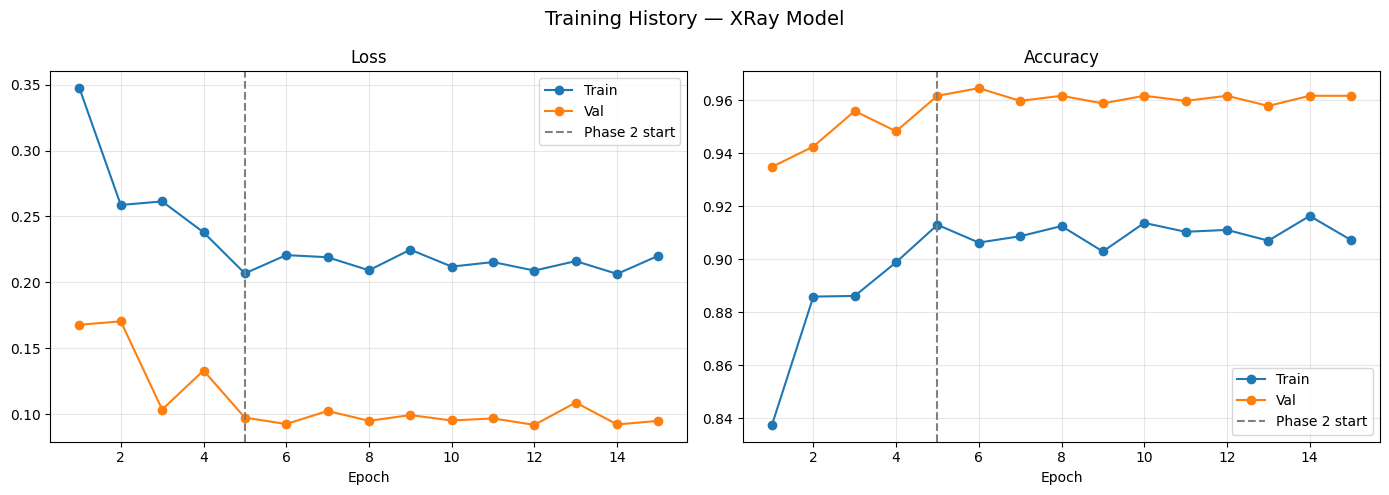

✅ Saved!


In [30]:
import pandas as pd

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(hist_df['epoch'], hist_df['tr_loss'], label='Train', marker='o')
axes[0].plot(hist_df['epoch'], hist_df['vl_loss'], label='Val',   marker='o')
axes[0].axvline(x=5, color='gray', linestyle='--', label='Phase 2 start')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(hist_df['epoch'], hist_df['tr_acc'], label='Train', marker='o')
axes[1].plot(hist_df['epoch'], hist_df['vl_acc'], label='Val',   marker='o')
axes[1].axvline(x=5, color='gray', linestyle='--', label='Phase 2 start')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — XRay Model', fontsize=14)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved!")

In [31]:
import json

config = {
    "model"          : "EfficientNet-B4",
    "modality"       : "xray",
    "num_classes"    : 2,
    "classes"        : ["Normal", "Pneumonia"],
    "image_size"     : 512,
    "best_threshold" : 0.7,
    "test_metrics": {
        "sensitivity" : 0.969,
        "specificity" : 0.709,
        "accuracy"    : 0.872,
        "f1_pneumonia": 0.89
    },
    "training": {
        "phase1_epochs": 5,
        "phase2_epochs": 10,
        "best_val_acc" : 0.965
    }
}

with open('/content/xray_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(json.dumps(config, indent=2))
print("✅ Config saved!")

{
  "model": "EfficientNet-B4",
  "modality": "xray",
  "num_classes": 2,
  "classes": [
    "Normal",
    "Pneumonia"
  ],
  "image_size": 512,
  "best_threshold": 0.7,
  "test_metrics": {
    "sensitivity": 0.969,
    "specificity": 0.709,
    "accuracy": 0.872,
    "f1_pneumonia": 0.89
  },
  "training": {
    "phase1_epochs": 5,
    "phase2_epochs": 10,
    "best_val_acc": 0.965
  }
}
✅ Config saved!


In [32]:
from google.colab import files

files.download('/content/xray_best.pth')
files.download('/content/xray_config.json')
files.download('/content/training_curves.png')
print("✅ Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded!
